# Customer Intelligence System Pipeline



In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/Country-data todsy.csv')
df.head()


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 1. Data Understanding & EDA

In [11]:

print('Shape:', df.shape)
display(df.info())
display(df.describe())
display(df.isnull().sum())


Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


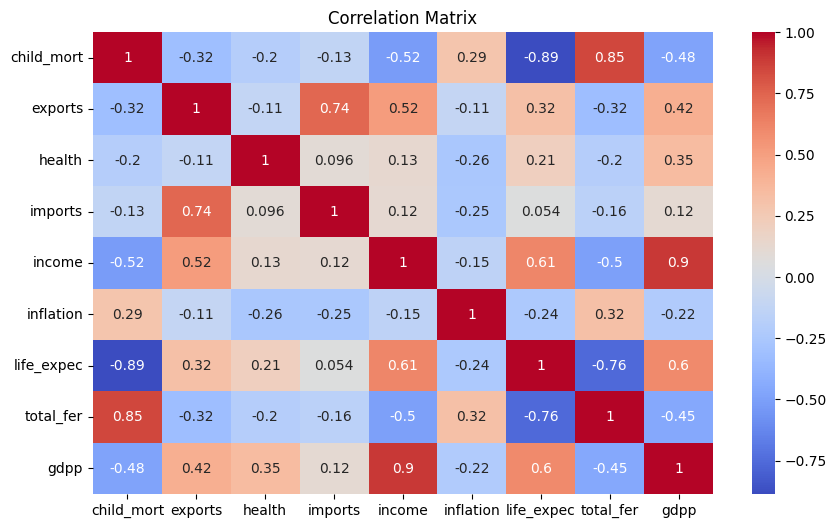

In [12]:

numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


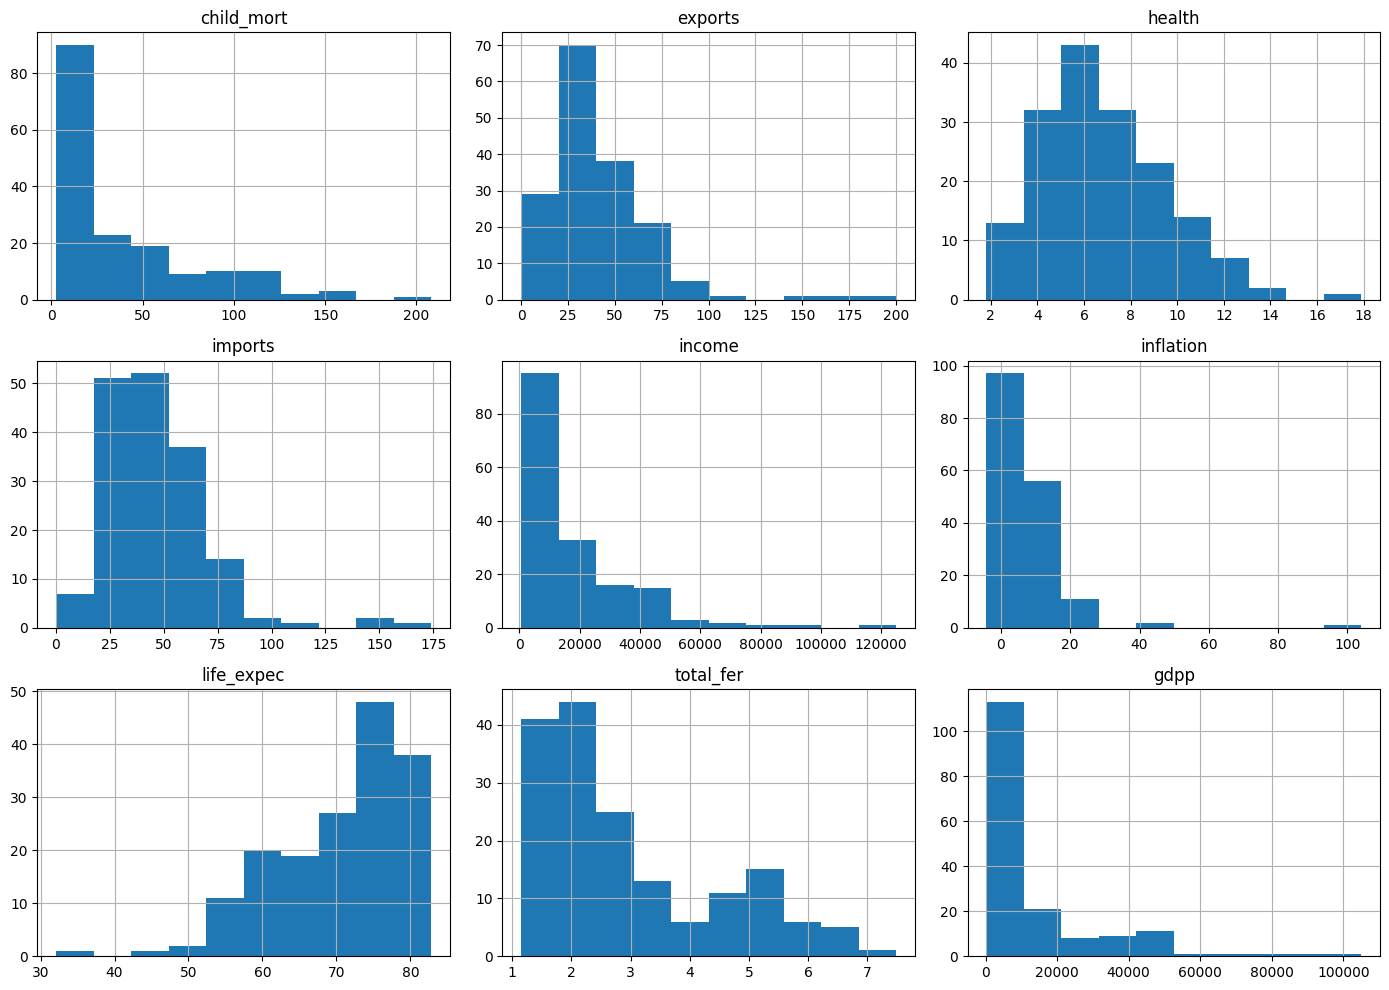

In [13]:

df[numeric_cols].hist(figsize=(14,10))
plt.tight_layout()
plt.show()


## 2. Preprocessing

In [14]:

X = df.drop(columns=['country'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 3. Customer/Country Segmentation using Clustering

In [15]:

silhouette_scores = {}

for k in range(2,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

best_k = max(silhouette_scores, key=silhouette_scores.get)
print('Best K:', best_k)
print(silhouette_scores)


Best K: 5
{2: np.float64(0.28735668921406704), 3: np.float64(0.28329575683463126), 4: np.float64(0.29595170577528157), 5: np.float64(0.2992594995920442), 6: np.float64(0.22869157246806018), 7: np.float64(0.2476808104838398), 8: np.float64(0.23881101831198853)}


In [16]:

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

print('KMeans Silhouette Score:', silhouette_score(X_scaled, df['segment']))
df[['country','segment']].head()


KMeans Silhouette Score: 0.2992594995920442


,country,segment
0,Afghanistan,1
1,Albania,0
2,Algeria,0
3,Angola,1
4,Antigua and Barbuda,0


In [17]:

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

print('Unique DBSCAN labels:', np.unique(db_labels))


Unique DBSCAN labels: [-1  0]


## 4. Build Predictive Model for Segment Prediction

In [18]:
counts = df['segment'].value_counts()
valid_classes = counts[counts >= 2].index

df_filtered = df[df['segment'].isin(valid_classes)]

X_model = X.loc[df_filtered.index]
y = df_filtered['segment']

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
print('RF CV Accuracy:', rf_cv.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


RF CV Accuracy: 0.93988603988604


In [20]:

rf_pipeline.fit(X_train, y_train)

train_pred = rf_pipeline.predict(X_train)
test_pred = rf_pipeline.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))


Train Accuracy: 0.9924242424242424
Test Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        10
           2       0.00      0.00      0.00         1
           3       0.86      1.00      0.92         6

    accuracy                           0.97        34
   macro avg       0.71      0.75      0.73        34
weighted avg       0.95      0.97      0.96        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42
    ))
])

xgb_cv = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='accuracy')
print('XGBoost CV Accuracy:', xgb_cv.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


XGBoost CV Accuracy: 0.9626780626780626


In [22]:

xgb_pipeline.fit(X_train, y_train)

train_pred = xgb_pipeline.predict(X_train)
test_pred = xgb_pipeline.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy:', accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))


Train Accuracy: 1.0
Test Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        10
           2       0.00      0.00      0.00         1
           3       0.86      1.00      0.92         6

    accuracy                           0.97        34
   macro avg       0.71      0.75      0.73        34
weighted avg       0.95      0.97      0.96        34



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
